In [1]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(SingleCellExperiment)
    library(Seurat)
    library(data.table)
    library(dplyr)
    library(gridExtra)
    library(viridis)
    
    library(edgeR)
    library(ggrastr)
    library(ggrepel)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

In [8]:
in_folder = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/'
counts = readMM(paste0(in_folder, "raw_counts.mtx"))
genes = read.table(paste0(in_folder, "genes.tsv"), stringsAsFactors = F)
meta = read.csv(paste0(in_folder, "meta.csv"), stringsAsFactors = F)

ERROR: Error in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, : line 2 did not have 2 elements


In [9]:
meta = read.csv(paste0(in_folder, "meta.csv"), stringsAsFactors = F)

In [10]:
rownames(counts) = genes[,1] #ensembl
colnames(counts) = meta$cell

In [11]:
sce = SingleCellExperiment(assays = list("counts" = counts))

In [12]:
sfs = read.table(paste0(in_folder, "sizefactors.tab"), stringsAsFactors = F)[,1]
sizeFactors(sce) = sfs
sce = scater::logNormCounts(sce)

In [15]:
sce = sce[, meta$stage=='E8.5']
meta = meta[meta$stage=='E8.5',]

ERROR: Error in `[.data.frame`(meta, , meta$stage == "E8.5"): undefined columns selected


In [18]:
genenames = fread("/rds/project/rds-SDzz0CATGms/users/bt392/gene_names.csv") %>% 
            setnames(c('ensembl_gene_id','external_gene_name'), c('gene', 'gene_name'))
genenames = genenames[genenames$gene %in% rownames(sce)]
genenames = merge(genenames, as.data.frame(rownames(sce)), by.x='gene', by.y='rownames(sce)', all.y=TRUE)
genenames$gene_name[genenames$gene_name==''] = NA
genenames[is.na(genenames$gene_name),] = genenames$gene[is.na(genenames$gene_name)]
genenames = genenames[order(match(genenames$gene, rownames(sce)))]
rownames(sce) = genenames$gene_name

In [19]:
sce

class: SingleCellExperiment 
dim: 29453 3531 
metadata(0):
assays(2): counts logcounts
rownames(29453): Xkr4 Gm1992 ... ENSMUSG00000095742 tomato-td
rowData names(0):
colnames(3531): cell_9951 cell_9952 ... cell_13480 cell_13481
colData names(1): sizeFactor
reducedDimNames(0):
altExpNames(0):

In [20]:
head(meta)

,cell,barcode,sample,stage,tomato,stage.mapped,celltype.mapped,doub.density
,<chr>,<chr>,<int>,<chr>,<lgl>,<chr>,<chr>,<dbl>
9951,cell_9951,AAACCTGAGACTGTAA,5,E8.5,TRUE,E8.25,Mesenchyme,0.152244489
9952,cell_9952,AAACCTGAGATGCCTT,5,E8.5,TRUE,E8.5,Endothelium,0.000296484
9953,cell_9953,AAACCTGAGCAGCCTC,5,E8.5,TRUE,E8.5,Allantois,0.110907032
9954,cell_9954,AAACCTGCATACTCTT,5,E8.5,TRUE,E8.5,Erythroid3,0.439766086
9955,cell_9955,AAACGGGTCAACACCA,5,E8.5,TRUE,E7.75,Erythroid1,0.294894978
9956,cell_9956,AAACGGGTCACTCTTA,5,E8.5,TRUE,E8.5,Endothelium,0.012190775


In [22]:
# genes that are different between KO & WT over the whole dataset
opts = list()
opts$min.logFC <- 1
opts$threshold_fdr = 0.01

sce_deg = sce
sce_deg$group = meta$tomato
out = findMarkers(sce_deg, sce_deg$group)[['TRUE']]
out$gene = rownames(out)
out = as.data.table(out) %>% 
    setnames(c('summary.logFC', 'FDR'), c('logFC', 'padj_fdr')) %>% 
     .[, log_padj_fdr := abs(log10(padj_fdr))] %>% 
     .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
     .[is.na(sig),sig:=FALSE] %>% 
     setorder(-sig, padj_fdr, na.last=T)

    out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]


In [24]:
gg_volcano_plot <- function(to.plot, top_genes=10, xlim=NULL, ylim=NULL, label_groups = NULL) {
  
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot)
  
  # if (is.null(xlim))
  #   xlim <- max(abs(to.plot$logFC), na.rm=T)
  # if (is.null(ylim))
  #   ylim <- max(-log10(to.plot$padj_fdr+1e-100), na.rm=T)
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)]
  
  p <- ggplot(to.plot, aes(x=logFC, y=-log10(padj_fdr+1e-100))) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=105), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-6,6)) +
    scale_y_continuous(limits=c(0,115)) +
    annotate("text", x=0, y=115, size=4, label=sprintf("(%d)", all)) +
    annotate("text", x=-5, y=115, size=4, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=5, y=115, size=4, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=head(to.plot[sig==T],n=top_genes), aes(x=logFC, y=-log10(padj_fdr+1e-100), label=gene), max.overlaps=Inf, size=4) +
    theme_classic() +
    theme(
      axis.text = element_text(size=rel(0.75), color='black'),
      axis.title = element_text(size=rel(1.0), color='black'),
      legend.position="none"
    )
  
  
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(p)
}

In [26]:
head(out, 20)

Top,p.value,padj_fdr,logFC,logFC.FALSE,gene,log_padj_fdr,sig
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<lgl>
1,0.00e+00,0.000000e+00,2.232,2.232260,H1f4,Inf,TRUE
2,0.00e+00,0.000000e+00,1.831,1.830961,Gm47283,Inf,TRUE
3,0.00e+00,0.000000e+00,1.965,1.964525,H1f5,Inf,TRUE
4,0.00e+00,0.000000e+00,1.161,1.161319,H1f1,Inf,TRUE
5,0.00e+00,0.000000e+00,1.264,1.263756,Dhx9,Inf,TRUE
6,0.00e+00,1.976263e-323,1.557,1.557426,ENSMUSG00000098178,322.704,TRUE
8,1.58e-302,5.820000e-299,1.207,1.207390,Prrc2c,298.235,TRUE
9,5.59e-287,1.830000e-283,1.335,1.334957,Kcnq1ot1,282.737,TRUE
11,2.05e-280,5.480000e-277,1.088,1.088202,Zdbf2,276.261,TRUE


In [33]:
pdf(sprintf('%sfindMarkers_DEGs_across_celltypes_WT.pdf', in_folder))
    gg_volcano_plot(out, 50) + ggtitle('DEGS in WT-injection')
dev.off()


png 
  2

In [34]:
write.csv(out, paste0(in_folder, 'tomato_DEGs_findMarkers.csv'), row.names=FALSE)

In [35]:
# Function to differential expression
# - sce: SingleCellExperiment object with the column "group" in the colData
# - groups: the names of the two groups
# - min_detection_rate_per_group: minimum detection rate per group
doDiffExpr <- function(sce, groups, min_detection_rate_per_group = 0.50) {
    
  # Sanity checks
  if (!is(sce, "SingleCellExperiment")) stop("'sce' has to be an instance of SingleCellExperiment")
  stopifnot(length(groups)==2)

  # Filter genes by detection rate per group
  cdr_A <- rowMeans(logcounts(sce[,sce$group==groups[1]])>0) >= min_detection_rate_per_group
  cdr_B <- rowMeans(logcounts(sce[,sce$group==groups[2]])>0) >= min_detection_rate_per_group
  out <- .edgeR(sce[cdr_B | cdr_A,]) %>% .[,log_padj_fdr:= -log10(padj_fdr)]
  
  return(out)
}


.edgeR <- function(sce) {
  
  # Convert SCE to DGEList
  
  sce_edger <- scran::convertTo(sce, type="edgeR")
 # sce_edger$samples$norm.factors = sce_edger$samples$sizeFactor
    
  # Define design matrix (with intercept)
  cdr <- colMeans(logcounts(sce)>0)
  design <- model.matrix(~cdr+sce$group)
  
  # Estimate dispersions
  sce_edger  <- estimateDisp(sce_edger,design)
  
  # Fit GLM
  fit <- glmQLFit(sce_edger,design)
  
  # Likelihood ratio test
  lrt <- glmQLFTest(fit)
  
  # Construct output data.frame
  out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
    setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
    .[,c("logCPM","LR"):=NULL]
  
  return(out)
}

In [50]:
sce$group = meta$tomato
opts$min.logFC <- 1
opts$threshold_fdr = 0.01

sce_deg = sce
opts$groups = c('TRUE', 'FALSE')
sce_deg$group = factor(sce_deg$group, levels = opts$groups)
print(opts$groups[1])

cdr.dt <- data.table(
  rownames(sce_deg),
  rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
  rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

out <- doDiffExpr(sce_deg, opts$groups) %>%
  # Add sample statistics
  .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
  .[,c("groupA","groupB"):=list(opts$groups[1],opts$groups[2])]%>%  
  # Add gene statistics
#  merge(cdr.dt, all.y=T, by="gene") %>%
  # Calculate statistical significance
  .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
  .[is.na(sig),sig:=FALSE] %>% 
  setorder(-sig, padj_fdr, na.last=T)

# Parse columns
out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]


[1] "TRUE"


In [64]:
summary(sce_deg$group)

TRUE FALSE 
 2454  1077

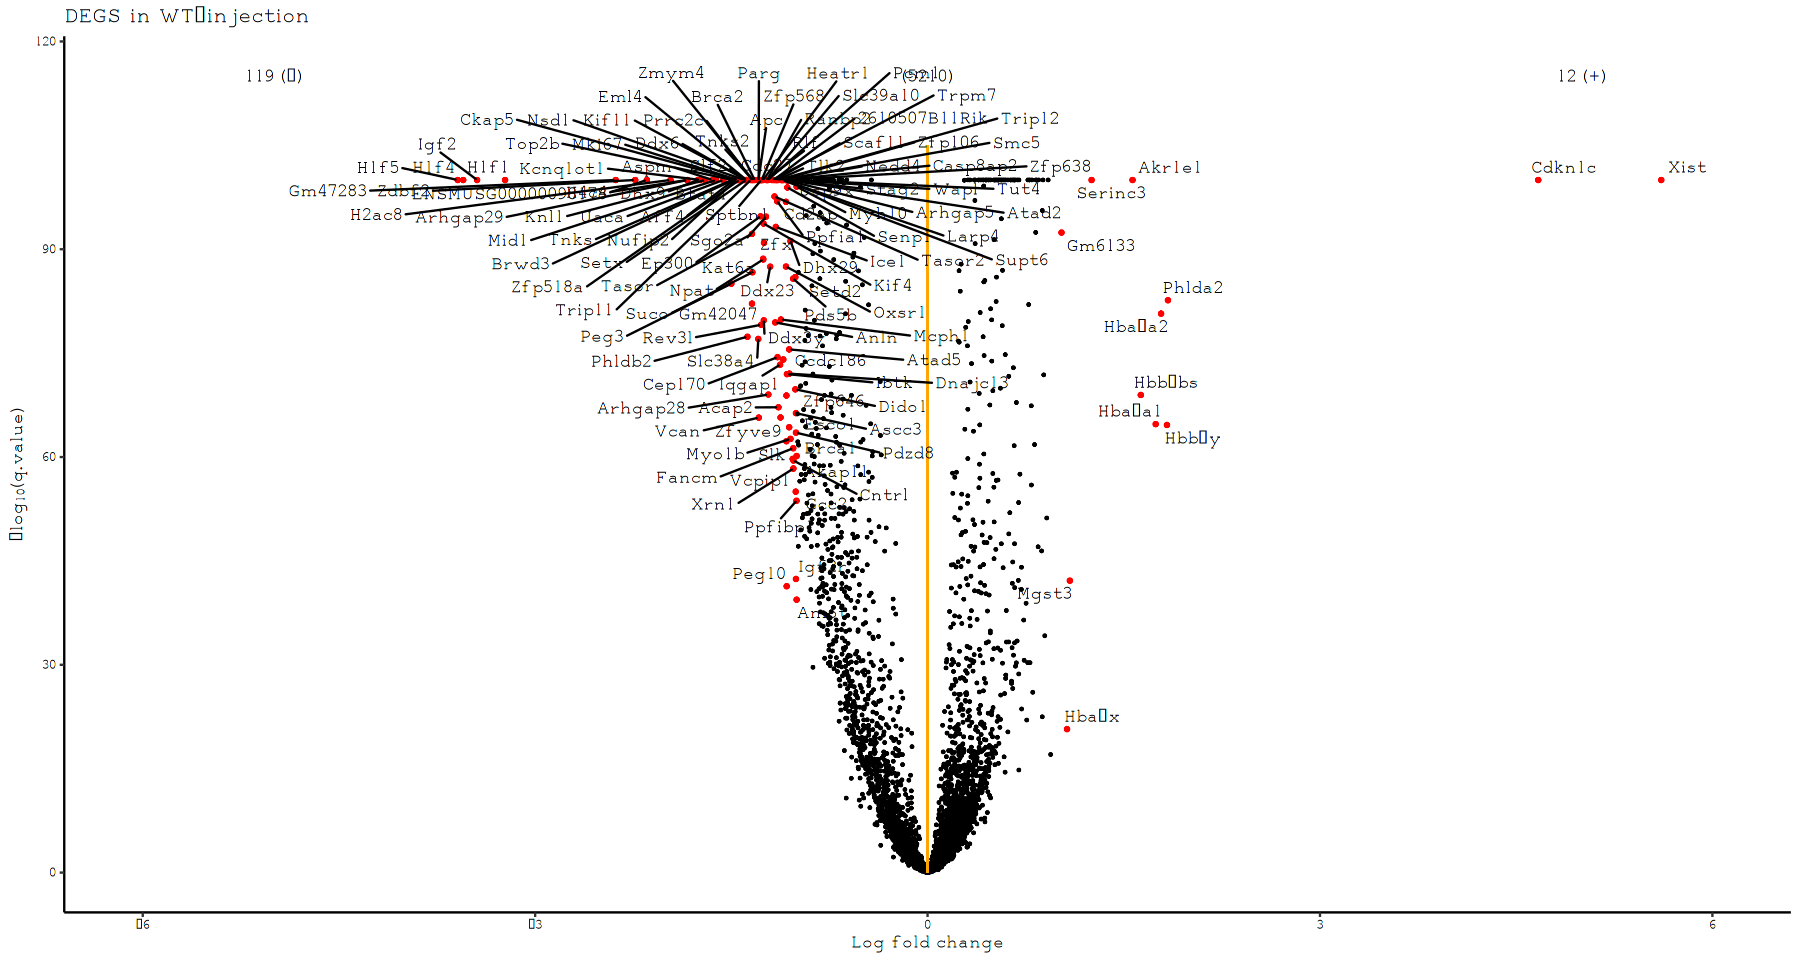

In [51]:
gg_volcano_plot(out, 200) + ggtitle('DEGS in WT-injection')

In [54]:
pdf(sprintf('%sedgeR_DEGs_across_celltypes_WT.pdf', in_folder))
    gg_volcano_plot(out, 200) + ggtitle('DEGS in WT-injection')
dev.off()


png 
  2

In [56]:
head(out, 100)

gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<lgl>
Xist,5.609,0.000000e+00,0.00e+00,Inf,2454,1077,TRUE,FALSE,TRUE
Cdkn1c,4.669,0.000000e+00,0.00e+00,Inf,2454,1077,TRUE,FALSE,TRUE
H1f5,-3.592,0.000000e+00,0.00e+00,Inf,2454,1077,TRUE,FALSE,TRUE
H1f4,-3.550,0.000000e+00,0.00e+00,Inf,2454,1077,TRUE,FALSE,TRUE
Gm47283,-2.384,0.000000e+00,0.00e+00,Inf,2454,1077,TRUE,FALSE,TRUE
Dhx9,-1.756,0.000000e+00,0.00e+00,Inf,2454,1077,TRUE,FALSE,TRUE
Prrc2c,-1.342,0.000000e+00,0.00e+00,Inf,2454,1077,TRUE,FALSE,TRUE
Scaf11,-1.165,0.000000e+00,0.00e+00,Inf,2454,1077,TRUE,FALSE,TRUE
Nedd4,-1.113,1.870038e-320,8.87e-318,317.052,2454,1077,TRUE,FALSE,TRUE


In [53]:
write.csv(out, paste0(in_folder, 'tomato_DEGs_edgeR.csv'), row.names=FALSE)

In [62]:
out[out$gene=='Hba-x',]

gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<lgl>
Hba-x,1.066,3.52e-22,1.95e-21,20.71,2454,1077,TRUE,FALSE,TRUE
